In [21]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import os, gc
import pickle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 데이터 경로
- 전처리 ver05

In [4]:
# 데이터 경로
print(os.getcwd())
path = '/content/drive/MyDrive/파이널 프로젝트/2025_07_09/' #'/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/'
prep_folder = os.listdir(path)
print(prep_folder)

/content
['분산(0.01),열의상관(0.7이상),Segment의상관(0.1이상)', '분산(0.01),열의상관(0.8이상),Segment의상관(0.1이상)', '분산(0.01),열의상관(0.8이상),Segment의상관(0.1이상,열의 상관중 Segment와 0.3이상 상관이 있으면 열삭제 x)']


In [5]:
print(os.listdir(path + prep_folder[2]))

['Segment_merge_ver_05.parquet', 'Segment_merge_test_ver_05.parquet']


In [6]:
# 데이터 로드
train = pd.read_parquet(path + prep_folder[2] + '/Segment_merge_ver_05.parquet')
test = pd.read_parquet(path + prep_folder[2] + '/Segment_merge_test_ver_05.parquet')

In [7]:
print(train.shape)
print(test.shape)

(2400000, 138)
(600000, 137)


In [14]:
# LightGBM 분석을 위한 전처리
## train data
drop_cols = ['기준년월', 'ID', 'Segment']
X = train.drop(drop_cols, axis=1)
y = train['Segment']

## test data
test_drop = test[X.columns]

## 확인
print(X.shape)
print(y.shape)
print(test_drop.shape)

(2400000, 135)
(2400000,)
(600000, 135)


In [15]:
# 1. 데이터 준비
# X: 특성 (DataFrame), y: 타깃 (Series: A~E)
# 가정: X, y는 이미 정의되어 있음

# 2. 1단계 라벨 재구성 (AB vs CDE)
y_bin = y.apply(lambda label: 'AB' if label in ['A', 'B'] else 'CDE')

# 3. 데이터 분리
X_train, X_test, y_bin_train, y_bin_test, y_train_full, y_test_full = train_test_split(
    X, y_bin, y, test_size=0.2, stratify=y, random_state=42
)


In [16]:
# 4. 1단계 이진 분류 모델 학습
binary_model = LGBMClassifier(random_state=42, class_weight='balanced')
binary_model.fit(X_train, y_bin_train)


[LightGBM] [Info] Number of positive: 1919107, number of negative: 893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.436091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24916
[LightGBM] [Info] Number of data points in the train set: 1920000, number of used features: 135
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', random_state=42)

In [17]:
# 5. 1단계 예측 (AB vs CDE)
bin_pred = binary_model.predict(X_test)

In [22]:
# 모델 저장
save_path = '/content/Mydiver/Colab_Notebooks/01.like_lion_final_prj/models/'


# 모델 저장
with open('AB_CDE_binary_model.pkl', 'wb') as f:
    pickle.dump(binary_model, f)

In [28]:
# 6. 2단계 분류 데이터셋 구성
# → 테스트 세트
X_test_ab = X_test[bin_pred == 'AB']
y_test_ab = y_test_full[bin_pred == 'AB']

X_test_cde = X_test[bin_pred == 'CDE']
y_test_cde = y_test_full[bin_pred == 'CDE']

# → 훈련 세트
X_train_ab = X_train[y_bin_train == 'AB']
y_train_ab = y_train_full[y_bin_train == 'AB']

X_train_cde = X_train[y_bin_train == 'CDE']
y_train_cde = y_train_full[y_bin_train == 'CDE']

In [29]:
# 7. 2단계 분류기 학습 (AB 모델, CDE 모델)
model_ab = LGBMClassifier(random_state=42)
model_ab.fit(X_train_ab, y_train_ab)

model_cde = LGBMClassifier(random_state=42)
model_cde.fit(X_train_cde, y_train_cde)


[LightGBM] [Info] Number of positive: 115, number of negative: 778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21888
[LightGBM] [Info] Number of data points in the train set: 893, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.128779 -> initscore=-1.911794
[LightGBM] [Info] Start training from score -1.911794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.453321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_

LGBMClassifier(random_state=42)

In [31]:
# 모델 저장
with open('ABCDE_classifier_model.pkl', 'wb') as f:
    pickle.dump(binary_model, f)

In [30]:
# 8. 2단계 예측
pred_ab = model_ab.predict(X_test_ab)
pred_cde = model_cde.predict(X_test_cde)

# 9. 최종 예측 결합
final_preds = pd.Series(index=X_test.index, dtype='object')
final_preds.loc[X_test_ab.index] = pred_ab
final_preds.loc[X_test_cde.index] = pred_cde

# 10. 평가
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test_full, final_preds))
print("\n📄 Classification Report:")
print(classification_report(y_test_full, final_preds))

📊 Confusion Matrix:
[[   185      1      8      0      0]
 [     0     26      3      0      0]
 [   516     50  15424   7200   2328]
 [    49      3   4572  45414  19810]
 [    37      3   1266  11641 371464]]

📄 Classification Report:
              precision    recall  f1-score   support

           A       0.24      0.95      0.38       194
           B       0.31      0.90      0.46        29
           C       0.73      0.60      0.66     25518
           D       0.71      0.65      0.68     69848
           E       0.94      0.97      0.95    384411

    accuracy                           0.90    480000
   macro avg       0.58      0.81      0.63    480000
weighted avg       0.90      0.90      0.90    480000



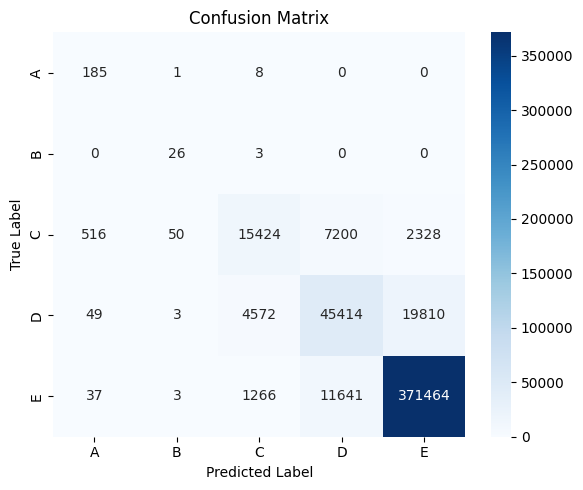

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 실제값과 예측값
# y_test_full: 실제 클래스 (ABCDE)
# final_preds: 예측 클래스 (ABCDE)

# 1. 혼동 행렬 계산
cm = confusion_matrix(y_test_full, final_preds, labels=['A', 'B', 'C', 'D', 'E'])

# 2. 라벨 정의
labels = ['A', 'B', 'C', 'D', 'E']

# 3. 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
### 대각선이 높을 수록 잘 맞춘 것
#### 1. A,B는 C와 혼동되지만 전체적으로 잘 분류 됨
#### 2. C는 D,E와 혼동
#### 3.

C, D, E 다중 분류기 사용

In [37]:
from imblearn.over_sampling import SMOTE
# 1) SMOTE 적용 (훈련 데이터에만)
smote = SMOTE(random_state=42)
X_train_cde_res, y_train_cde_res = smote.fit_resample(X_train_cde, y_train_cde)

# 2) 모델 학습
model_cde = LGBMClassifier(random_state=42, class_weight='balanced')
model_cde.fit(X_train_cde_res, y_train_cde_res)

# 3) 예측 및 평가
pred_cde = model_cde.predict(X_test_cde)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.781156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25201
[LightGBM] [Info] Number of data points in the train set: 4612923, number of used features: 135
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [35]:
# 최종 예측 결합
final_preds = pd.Series(index=X_test.index, dtype='object')
final_preds.loc[X_test_ab.index] = pred_ab
final_preds.loc[X_test_cde.index] = pred_cde

# 평가
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test_full, final_preds))
print("\n📄 Classification Report:")
print(classification_report(y_test_full, final_preds))

📊 Confusion Matrix:
[[   185      1      8      0      0]
 [     0     26      3      0      0]
 [   516     50  19405   4399   1148]
 [    49      3   9987  47924  11885]
 [    37      3   4781  27324 352266]]

📄 Classification Report:
              precision    recall  f1-score   support

           A       0.24      0.95      0.38       194
           B       0.31      0.90      0.46        29
           C       0.57      0.76      0.65     25518
           D       0.60      0.69      0.64     69848
           E       0.96      0.92      0.94    384411

    accuracy                           0.87    480000
   macro avg       0.54      0.84      0.61    480000
weighted avg       0.89      0.87      0.88    480000



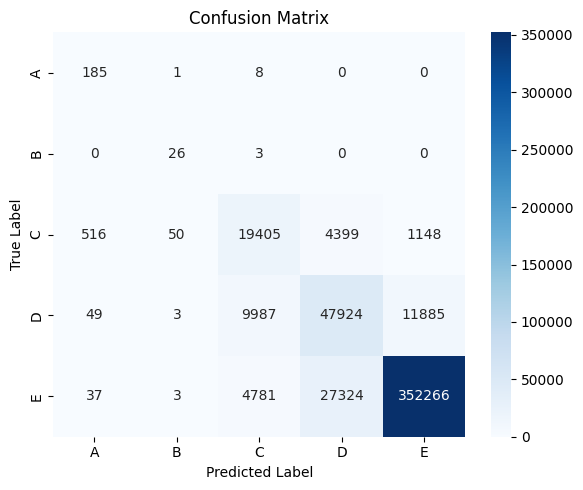

In [36]:
# 1. 혼동 행렬 계산
cm = confusion_matrix(y_test_full, final_preds, labels=['A', 'B', 'C', 'D', 'E'])

# 2. 라벨 정의
labels = ['A', 'B', 'C', 'D', 'E']

# 3. 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### 결과 예측

In [39]:
# 5. 1단계 예측 (AB vs CDE)
bin_pred_final = binary_model.predict(test_drop)

# AB와 CDE 분리
X_test_ab_final = test_drop[bin_pred_final == 'AB']
X_test_cde_final = test_drop[bin_pred_final == 'CDE']

# 8. 2단계 예측 A/B, C/D/E
# A/B 예측
pred_ab_final = model_ab.predict(X_test_ab_final)

# C/D/E 예측
pred_cde_final = model_cde.predict(X_test_cde_final)

# 9. 최종 예측 결합
# 빈 시리즈 생성
final_preds = pd.Series(index=test_drop.index, dtype='object')

# 인덱스에 맞게 예측 결과 넣기
final_preds.loc[X_test_ab_final.index] = pred_ab_final
final_preds.loc[X_test_cde_final.index] = pred_cde_final

# ID와 함께 붙이기
submission = pd.DataFrame({
    'ID': test['ID'],  # test.csv에 ID 컬럼이 있다고 가정
    'Segment': final_preds.values
})

# submission.to_csv('submission.csv', index=False)

In [40]:
submission.Segment.value_counts()

,count
Segment,
E,457162
D,98981
C,42608
A,1165
B,84


In [41]:
len(submission)

600000

In [42]:
submission_unique = submission.groupby('ID')['Segment'].agg(lambda x: x.mode().iloc[0]).reset_index()
submission_unique.Segment.value_counts()

,count
Segment,
E,75966
D,16633
C,7194
A,196
B,11


In [43]:
  submission_unique.to_csv(f'/content/drive/MyDrive/Colab_Notebooks/submission_0711_AB_CDE_이진분류후_CDE다중분류.csv', index=False)

soft voting 적용

In [45]:
import pandas as pd
import numpy as np

# 1단계 예측: 확률 기반
bin_proba = binary_model.predict_proba(test_drop)
bin_classes = binary_model.classes_  # ['AB', 'CDE']
bin_pred_final = np.where(bin_proba[:, bin_classes == 'AB'].flatten() > 0.5, 'AB', 'CDE')

# 2단계 분할
X_test_ab_final = test_drop[bin_pred_final == 'AB']
X_test_cde_final = test_drop[bin_pred_final == 'CDE']

# 2단계 예측: 확률 기반
# A/B 예측 확률
ab_proba = model_ab.predict_proba(X_test_ab_final)
ab_classes = model_ab.classes_

# C/D/E 예측 확률
cde_proba = model_cde.predict_proba(X_test_cde_final)
cde_classes = model_cde.classes_

# 확률을 DataFrame으로 변환
ab_df = pd.DataFrame(ab_proba, index=X_test_ab_final.index, columns=ab_classes)
cde_df = pd.DataFrame(cde_proba, index=X_test_cde_final.index, columns=cde_classes)

# 전체 예측 확률 프레임 구성
all_classes = ['A', 'B', 'C', 'D', 'E']
proba_df = pd.DataFrame(0, index=test_drop.index, columns=all_classes)

proba_df.loc[X_test_ab_final.index, ab_classes] = ab_df
proba_df.loc[X_test_cde_final.index, cde_classes] = cde_df
proba_df['ID'] = test['ID'].values  # test와 같은 순서라고 가정

# ID별 확률 평균 (soft voting)
grouped_proba = proba_df.groupby('ID')[all_classes].mean()

# 확률이 가장 높은 클래스 선택
final_preds = grouped_proba.idxmax(axis=1)

# 제출 파일 작성
submission = pd.DataFrame({
    'ID': final_preds.index,
    'Segment': final_preds.values
})

# submission.to_csv('submission_soft_voting.csv', index=False)


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. y_true가 있다고 가정 (예: label_df: ID와 정답 Segment 포함)
# ID를 기준으로 정렬하여 y_true 추출
y_true = tra.set_index('ID').loc[final_preds.index]['Segment']

# 2. 혼동 행렬 계산
cm = confusion_matrix(y_true, final_preds, labels=['A', 'B', 'C', 'D', 'E'])

# 3. 시각화
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D', 'E'],
            yticklabels=['A', 'B', 'C', 'D', 'E'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Soft Voting)')
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['TEST_00000', 'TEST_00001', 'TEST_00002', 'TEST_00003', 'TEST_00004',\n       'TEST_00005', 'TEST_00006', 'TEST_00007', 'TEST_00008', 'TEST_00009',\n       ...\n       'TEST_99990', 'TEST_99991', 'TEST_99992', 'TEST_99993', 'TEST_99994',\n       'TEST_99995', 'TEST_99996', 'TEST_99997', 'TEST_99998', 'TEST_99999'],\n      dtype='object', name='ID', length=100000)] are in the [index]"

In [46]:
submission.Segment.value_counts()

,count
Segment,
E,77252
D,16008
C,6534
A,193
B,13


In [50]:
  submission_unique.to_csv(f'/content/drive/MyDrive/Colab_Notebooks/submission_0711_AB_CDE_이진분류후_CDE다중분류_softvoting.csv', index=False)